In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import SPSA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.utils import algorithm_globals

2026-06-05 10:53:45.045482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-05 10:53:45.060636: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 10:53:45.640599: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-05 10:53:48.014500: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

# DATASETS

In [3]:
# datasets
SEED = 42

# changing it because it requires 4 inputs
X_class, y_class = make_classification(
    n_samples=200,
    n_features=4,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# synthetic dataset
X_s = X_class
y_s = y_class
X_s_tr, X_s_test, y_s_tr, y_s_test = train_test_split(
    X_s,
    y_s,
    test_size=0.4,
    random_state=SEED
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_s_tr = scaler.fit_transform(X_s_tr)
X_s_test = scaler.transform(X_s_test)


# this is already present in the full code - TO REMOVE
iris = load_iris(as_frame=True)

X = iris.data       
y = iris.target     

#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)


# binary dataset - setosa vs virginica
# already splitted and scaled above
X_b_tr = X_train_sv
X_b_test = X_test_sv
y_b_tr = y_train_sv
y_b_test = y_test_sv

# MODELS

In [4]:
'''
UPDATED VERSION OF THE CL MODEL WITH 60 PARAMETERS
'''

def build_model2(input_lenght=4, depth=2, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# defining models
CL_model = build_model2(input_lenght=4, depth=5, n_class=2) 

/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-05 10:53:51.429229: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


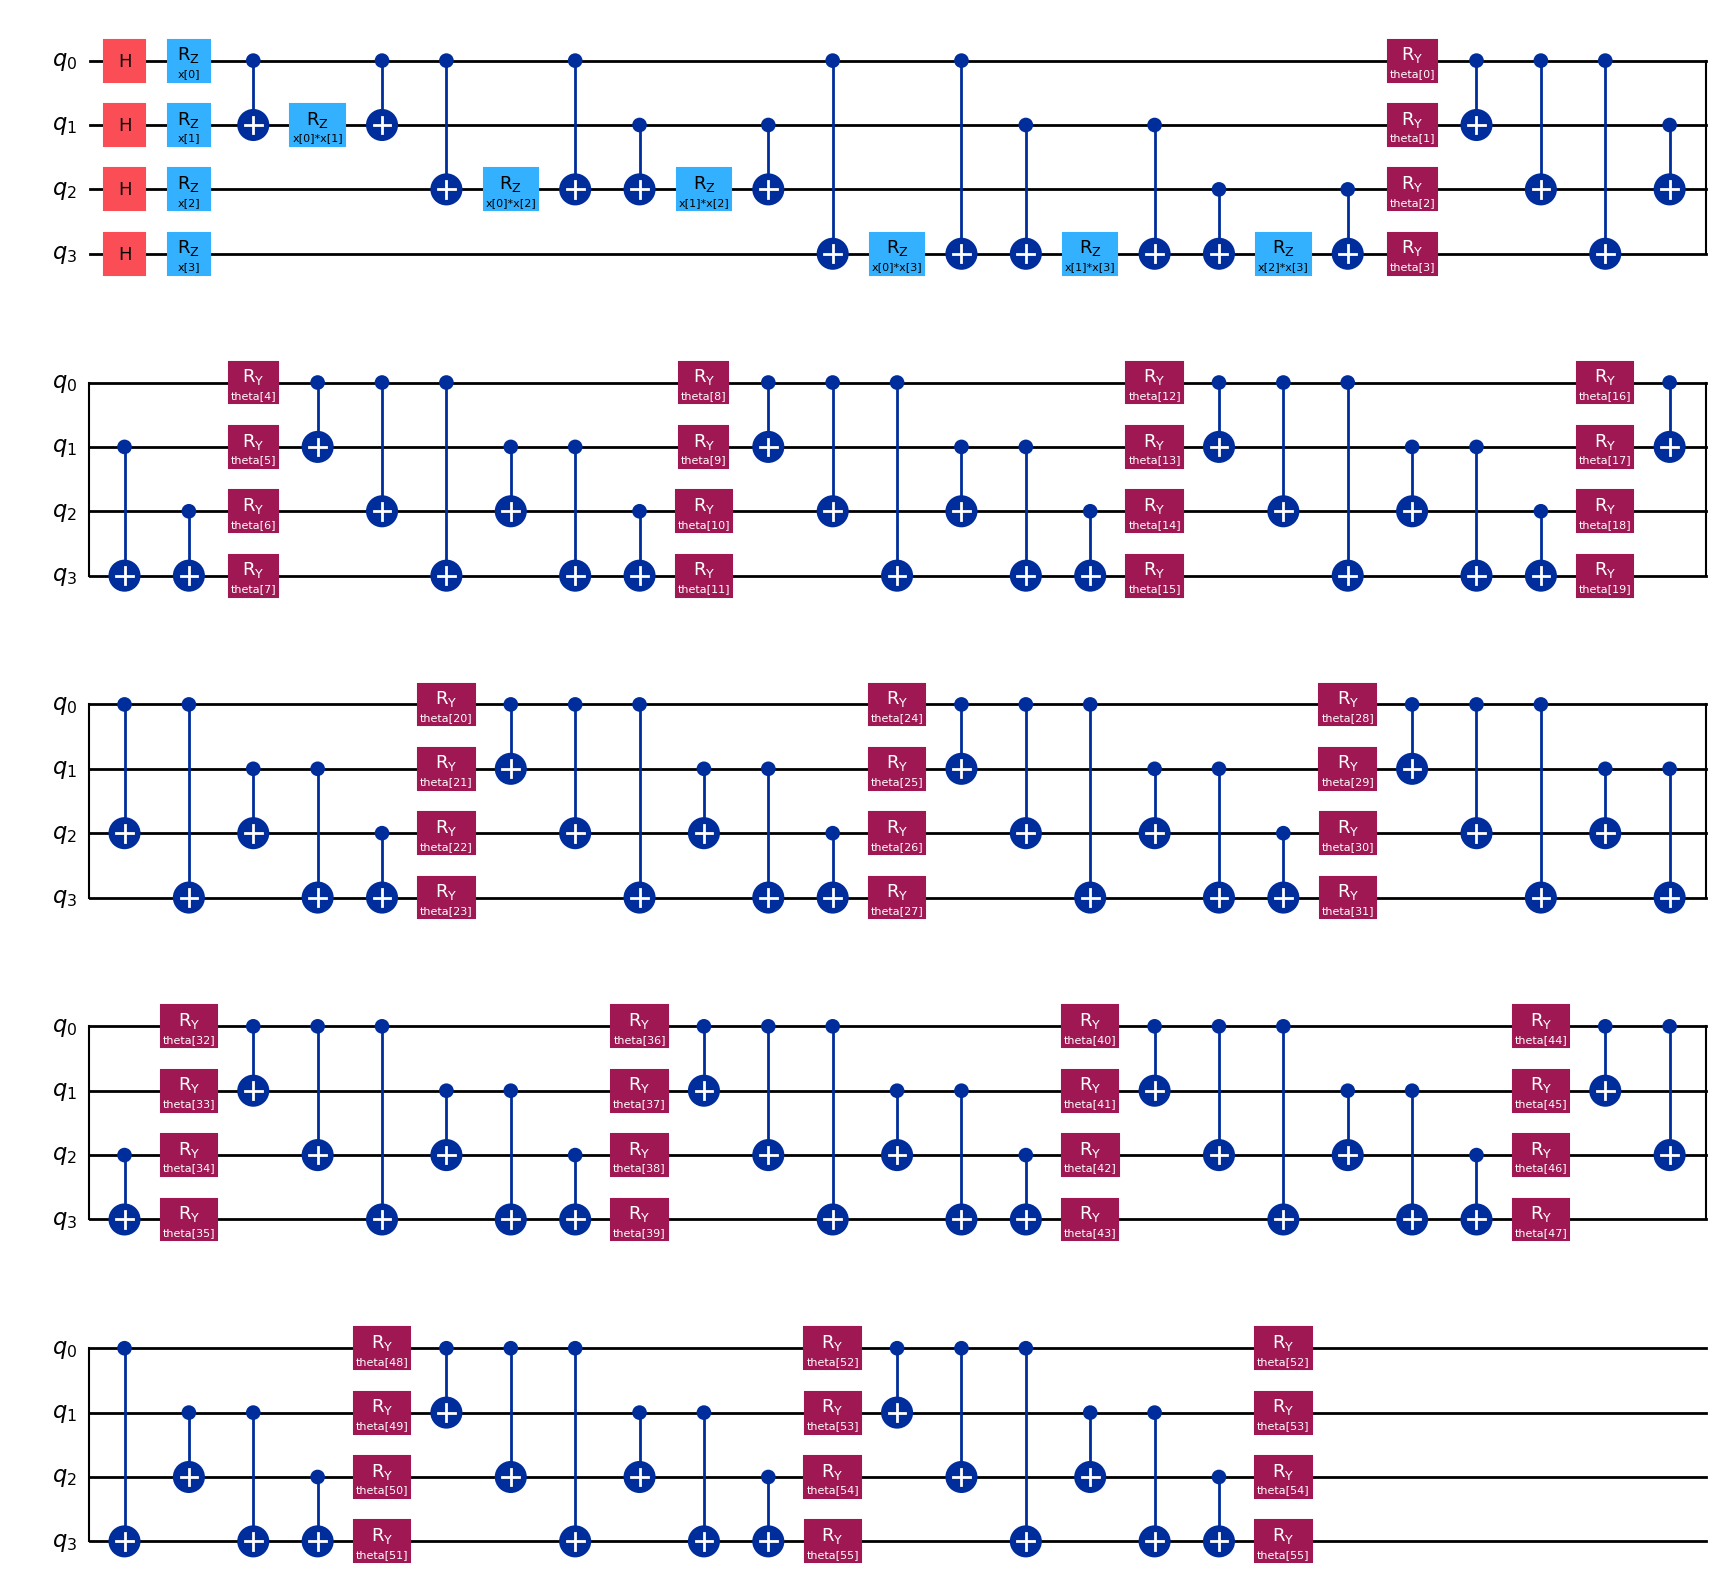

In [5]:
'''
QNN and EASY QNN with 60 parameters
'''

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc



# to have a QNN with 60 trainable parameters

def Ansatz_60_par(n_bits):
    theta = ParameterVector('theta', 15*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(14):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,N):
                qc.cx(i, j)
        qc.barrier()
    for i in range(n_bits):    
        qc.ry(theta[i+l*n_bits], i)
    qc.barrier()

    return qc

# defining models
N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz_60_par(N)


qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

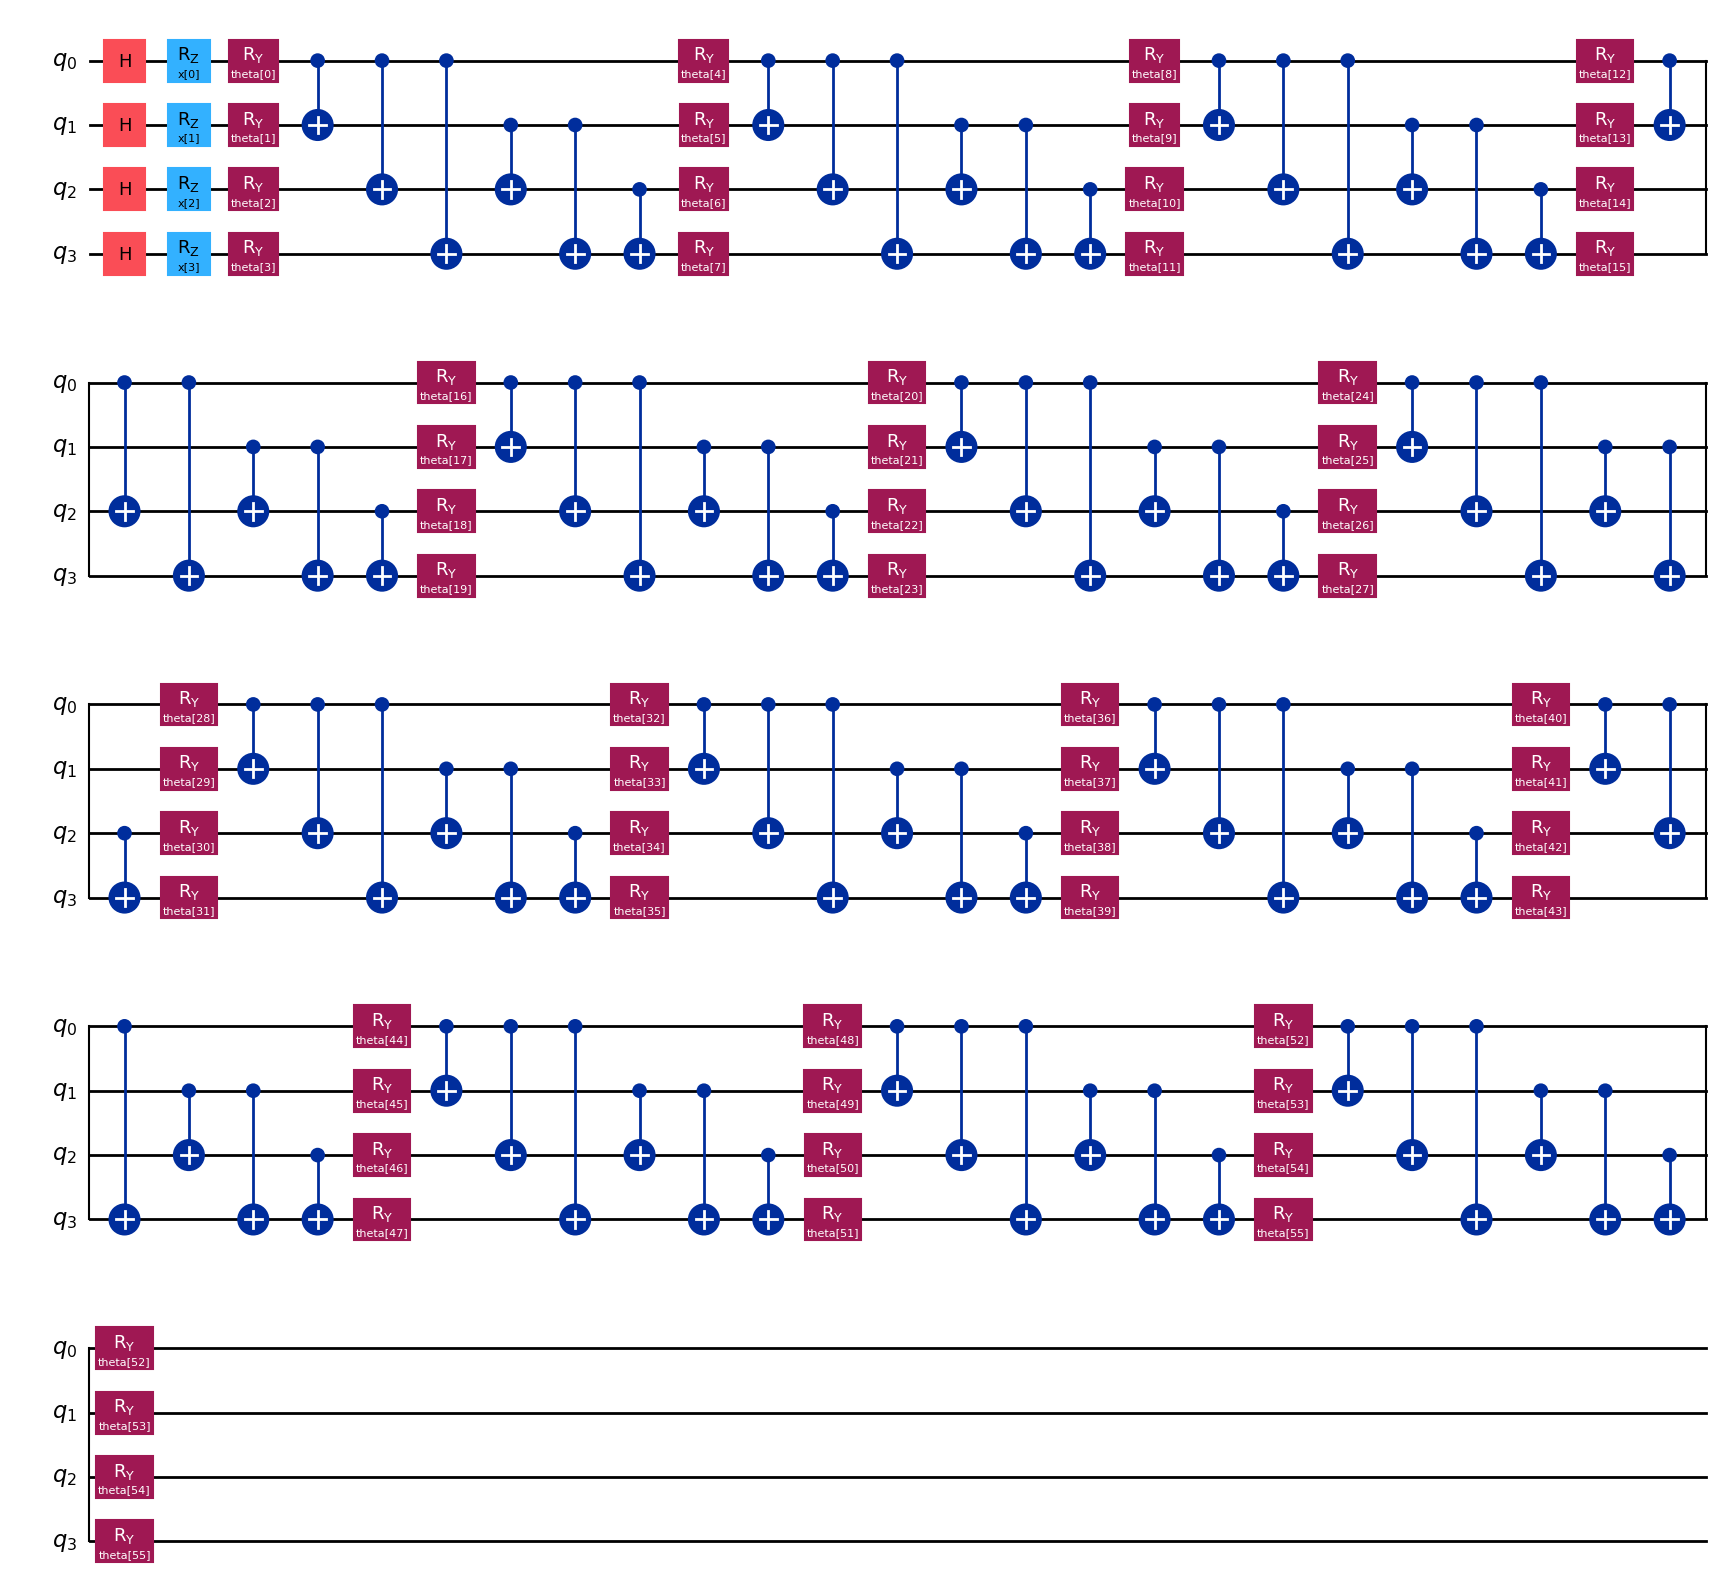

In [6]:
# defining models
# easy quantum model

qc_easy = easy_feature_map.copy().compose(ansatz.copy())
qc_easy.draw("mpl", style="iqp", plot_barriers=False)

# CL MODEL, QNN, EASY QNN - SYNTHETIC DATASET

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from numpy import random

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import SPSA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.utils import algorithm_globals

'''
CHANGE n_runs
'''
n_runs = 5 # TO CHANGE
n_iter = 100 

cl_all_losses = []
cl_all_accs = []
q_all_losses = []
q_all_accs = []
eq_all_losses = []
eq_all_accs = []

# Function to get the loss value
def make_adam_tracker(loss_list, maxiter=100, N=4):
    log_n = np.log2(N)
    def adam_with_tracking(fun, x0, jac=None, **kwargs):
        optimizer = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(weights):
            loss = fun(weights)
            loss_norm = float(loss) / log_n
            loss_list.append(float(loss_norm))
            #pct = len(loss_list)/maxiter * 100
            #bar = "#"*int( pct//5 ) + "."*( 20 - int(pct//5) )  
            #print(f"\r[{bar}] iter {len(loss_list):>3d} | loss: {loss:.4f}",flush=True)
            return jac(weights)
        return optimizer.minimize(fun=fun, x0=x0, jac=tracked_jac)
    return adam_with_tracking


def run(seed):

    algorithm_globals.random_seed = seed
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    # loss and weights
    cl_loss = []
    q_loss = []
    eq_loss = []
    
    cl_acc = []
    q_weights = []
    eq_weights = []

    # functions
    def callback_graph(nfev, x, fx, step_size, accepted):
        q_weights.append(x.copy())
        q_loss.append(fx)

    def e_callback_graph(nfev, x, fx, step_size, accepted):
        eq_weights.append(x.copy())
        eq_loss.append(fx)

    # models
    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(q_loss), 
        callback=callback_graph,
        sampler=StatevectorSampler(),
    )

    e_vqc = VQC(
        feature_map=easy_feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(eq_loss),  
        callback=e_callback_graph,
        sampler=StatevectorSampler(),
    )

    CL_model = build_model2(input_lenght=4, depth=5, n_class=2) 


    # fit
    vqc.fit(X_s_tr, y_s_tr)

    e_vqc.fit(X_s_tr, y_s_tr)
    
    history = model.fit(
        X_s_tr, y_s_tr,
        validation_data=(X_s_test, y_s_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        shuffle=True
    )

    # accuracy and loss
    q_acc = []
    eq_acc = []
    
    for w in q_weights:
        outputs = vqc.neural_network.forward(X_s_test, w)
        preds = np.argmax(outputs, axis=1)
        q_acc.append(accuracy_score(y_s_test, preds))

    for w in eq_weights:
        outputs = e_vqc.neural_network.forward(X_s_test, w)
        preds = np.argmax(outputs, axis=1)
        eq_acc.append(accuracy_score(y_s_test, preds))

    loss = np.array(history.history['loss'])
    cl_loss.append(loss)
    
    val_acc = np.array(history.history['val_accuracy'])
    cl_acc.append(val_acc)
    

    return np.array(cl_loss), np.array(q_loss),np.array(eq_loss), np.array(cl_acc), np.array(q_acc), np.array(eq_acc)

# runs
for seed in range(n_runs):
    print(f"Running seed {seed}")
    cll, ql, eql, clacc, qacc, eqacc = run(seed)
    cl_all_losses.append(cll)
    cl_all_accs.append(clacc)
    q_all_losses.append(ql)
    q_all_accs.append(qacc)
    eq_all_losses.append(eql)
    eq_all_accs.append(eqacc)


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Running seed 0


/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)

KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
cl_all_losses = np.array(cl_all_losses) # (n_run, n_iter)
cl_all_accs = np.array(cl_all_accs)
q_all_losses = np.array(q_all_losses)
q_all_accs = np.array(q_all_accs)
eq_all_losses = np.array(eq_all_losses)
eq_all_accs = np.array(eq_all_accs)


# mean and std
cl_loss_mean = cl_all_losses.mean(axis=0).ravel()
cl_loss_std = cl_all_losses.std(axis=0).ravel()
cl_accs_mean = cl_all_accs.mean(axis=0).ravel()
cl_accs_std = cl_all_accs.std(axis=0).ravel()

q_loss_mean = q_all_losses.mean(axis=0).ravel()
q_loss_std = q_all_losses.std(axis=0).ravel()
q_accs_mean = q_all_accs.mean(axis=0).ravel()
q_accs_std = q_all_accs.std(axis=0).ravel()

eq_loss_mean = eq_all_losses.mean(axis=0).ravel()
eq_loss_std = eq_all_losses.std(axis=0).ravel()
eq_accs_mean = eq_all_accs.mean(axis=0).ravel()
eq_accs_std = eq_all_accs.std(axis=0).ravel()


In [ ]:
# plot loss
plt.figure(figsize=(12,5))

plt.plot(cl_loss_mean, label="Mean CL loss", c='r')
plt.fill_between(
    range(n_iter),
    cl_loss_mean - cl_loss_std,
    cl_loss_mean + cl_loss_std,
    color='r',
    alpha=0.3
)

plt.plot(q_loss_mean, label="Mean QNN loss", c='b')
plt.fill_between(
    range(n_iter),
    q_loss_mean - q_loss_std,
    q_loss_mean + q_loss_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_loss_mean, label="Mean EASY QNN loss", c='g')
plt.fill_between(
    range(n_iter),
    eq_loss_mean - eq_loss_std,
    eq_loss_mean + eq_loss_std,
    color='g',
    alpha=0.3
)

plt.title("Training Loss over synthetic dataset")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()


# plot accuracy
plt.figure(figsize=(12,5))

plt.plot(cl_accs_mean, label="Mean CL accuracy", c='r')
plt.fill_between(
    range(n_iter),
    cl_accs_mean - cl_accs_std,
    cl_accs_mean + cl_accs_std,
    color='r',
    alpha=0.3
)

plt.plot(q_accs_mean, label="Mean QNN accuracy", c='b')
plt.fill_between(
    range(n_iter),
    q_accs_mean - q_accs_std,
    q_accs_mean + q_accs_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_accs_mean, label="Mean EASY QNN accuracy", c='g')
plt.fill_between(
    range(n_iter),
    eq_accs_mean - eq_accs_std,
    eq_accs_mean + eq_accs_std,
    color='g',
    alpha=0.3
)

plt.title("Test Accuracy over synthetic dataset")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()

# CL MODEL, QNN, EASY QNN - BINARY DATASET

In [ ]:
y_b_tr = np.asarray(y_b_tr)
y_b_test = np.asarray(y_b_test)

In [ ]:
n_runs = 1 # TO CHANGE
n_iter = 100 

cl_all_losses = []
cl_all_accs = []
q_all_losses = []
q_all_accs = []
eq_all_losses = []
eq_all_accs = []


def run(seed):

    algorithm_globals.random_seed = seed
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    # loss and weights
    cl_loss = []
    q_loss = []
    eq_loss = []
    
    cl_acc = []
    q_weights = []
    eq_weights = []

    # functions
    def callback_graph(nfev, x, fx, step_size, accepted):
        q_weights.append(x.copy())
        q_loss.append(fx)

    def e_callback_graph(nfev, x, fx, step_size, accepted):
        eq_weights.append(x.copy())
        eq_loss.append(fx)

    # models
    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(q_loss),
        callback=callback_graph,
        sampler=StatevectorSampler(),
    )

    e_vqc = VQC(
        feature_map=easy_feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(eq_loss),
        callback=e_callback_graph,
        sampler=StatevectorSampler(),
    )

    CL_model = build_model2(input_lenght=4, depth=5, n_class=2) 


    # fit
    vqc.fit(X_b_tr, y_b_tr)

    e_vqc.fit(X_b_tr, y_b_tr)
    
    history = model.fit(
        X_b_tr, y_b_tr,
        validation_data=(X_b_test, y_b_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        shuffle=True
    )

    # accuracy and loss
    q_acc = []
    eq_acc = []
    
    for w in q_weights:
        outputs = vqc.neural_network.forward(X_b_test, w)
        preds = np.argmax(outputs, axis=1)
        q_acc.append(accuracy_score(y_b_test, preds))

    for w in eq_weights:
        outputs = e_vqc.neural_network.forward(X_b_test, w)
        preds = np.argmax(outputs, axis=1)
        eq_acc.append(accuracy_score(y_b_test, preds))

    loss = np.array(history.history['loss'])
    cl_loss.append(loss)
    
    val_acc = np.array(history.history['val_accuracy'])
    cl_acc.append(val_acc)
    

    return np.array(cl_loss), np.array(q_loss),np.array(eq_loss), np.array(cl_acc), np.array(q_acc), np.array(eq_acc)

# runs
for seed in range(n_runs):
    print(f"Running seed {seed}")
    cll, ql, eql, clacc, qacc, eqacc = run(seed)
    cl_all_losses.append(cll)
    cl_all_accs.append(clacc)
    q_all_losses.append(ql)
    q_all_accs.append(qacc)
    eq_all_losses.append(eql)
    eq_all_accs.append(eqacc)


In [ ]:
cl_all_losses = np.array(cl_all_losses) # (n_run, n_iter)
cl_all_accs = np.array(cl_all_accs)
q_all_losses = np.array(q_all_losses)
q_all_accs = np.array(q_all_accs)
eq_all_losses = np.array(eq_all_losses)
eq_all_accs = np.array(eq_all_accs)


# mean and std
cl_loss_mean = cl_all_losses.mean(axis=0).ravel()
cl_loss_std = cl_all_losses.std(axis=0).ravel()
cl_accs_mean = cl_all_accs.mean(axis=0).ravel()
cl_accs_std = cl_all_accs.std(axis=0).ravel()

q_loss_mean = q_all_losses.mean(axis=0).ravel()
q_loss_std = q_all_losses.std(axis=0).ravel()
q_accs_mean = q_all_accs.mean(axis=0).ravel()
q_accs_std = q_all_accs.std(axis=0).ravel()

eq_loss_mean = eq_all_losses.mean(axis=0).ravel()
eq_loss_std = eq_all_losses.std(axis=0).ravel()
eq_accs_mean = eq_all_accs.mean(axis=0).ravel()
eq_accs_std = eq_all_accs.std(axis=0).ravel()


In [ ]:
# plot loss
plt.figure(figsize=(12,5))

plt.plot(cl_loss_mean, label="Mean CL loss", c='r')
plt.fill_between(
    range(n_iter),
    cl_loss_mean - cl_loss_std,
    cl_loss_mean + cl_loss_std,
    color='r',
    alpha=0.3
)

plt.plot(q_loss_mean, label="Mean QNN loss", c='b')
plt.fill_between(
    range(n_iter),
    q_loss_mean - q_loss_std,
    q_loss_mean + q_loss_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_loss_mean, label="Mean EASY QNN loss", c='g')
plt.fill_between(
    range(n_iter),
    eq_loss_mean - eq_loss_std,
    eq_loss_mean + eq_loss_std,
    color='g',
    alpha=0.3
)

plt.title("Training Loss over the binary dataset ")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()


# plot accuracy
plt.figure(figsize=(12,5))

plt.plot(cl_accs_mean, label="Mean CL accuracy", c='r')
plt.fill_between(
    range(n_iter),
    cl_accs_mean - cl_accs_std,
    cl_accs_mean + cl_accs_std,
    color='r',
    alpha=0.3
)

plt.plot(q_accs_mean, label="Mean QNN accuracy", c='b')
plt.fill_between(
    range(n_iter),
    q_accs_mean - q_accs_std,
    q_accs_mean + q_accs_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_accs_mean, label="Mean EASY QNN accuracy", c='g')
plt.fill_between(
    range(n_iter),
    eq_accs_mean - eq_accs_std,
    eq_accs_mean + eq_accs_std,
    color='g',
    alpha=0.3
)

plt.title("Test Accuracy over the binary dataset")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()